# 3.1 — Основные метрики и калибровка

**Папка 3 «Оценка», подноутбук 1.** Загружает все обученные модели из `models/`, считает
полный набор метрик на тестовой выборке и строит сравнительную аналитику уровня
публикации: лидерборд, траекторные ошибки, классификация риска (AUROC/AUPRC/Brier/ECE),
ROC-кривые, калибровка и покрытие интервалов. Все рисунки и таблицы — на английском.

## Окружение, данные и модели

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "demo_run"
MODELS_DIR = REPO_ROOT / "models"

import torch

from liquefaction_ai import load_population_artifact, prepare_benchmark_dataset
from liquefaction_ai.training import load_model_metadata, load_weights_into
from liquefaction_ai.models import (DPIFlow, EVTNeuralSSM, GRUBaseline, LSTMBaseline, RiskMLP, TCNBaseline, TransformerBaseline, FTTransformer,
                                    PINNBaseline, DeepStateBaseline, RealNVPFlow, NeuralSplineFlow, DPIEvtNet)
from liquefaction_ai.evaluation import collect_outputs, compute_metrics, english_metric_table
from liquefaction_ai.models import CatBoostBaseline

CLASS_REGISTRY = {"RiskMLP": RiskMLP, "GRUBaseline": GRUBaseline, "TCNBaseline": TCNBaseline, "LSTMBaseline": LSTMBaseline, "TransformerBaseline": TransformerBaseline, "FTTransformer": FTTransformer, "PINNBaseline": PINNBaseline, "DeepStateBaseline": DeepStateBaseline, "RealNVPFlow": RealNVPFlow, "NeuralSplineFlow": NeuralSplineFlow,
                  "DPIFlow": DPIFlow, "EVTNeuralSSM": EVTNeuralSSM, "DPIEvtNet": DPIEvtNet}
MODEL_NAMES = ["mlp_risk", "gru", "tcn", "lstm", "transformer", "ft_transformer", "pinn", "deepstate", "realnvp", "nsf", "dpi_flow", "evt_ssm", "dpi_evt"]

population, config = load_population_artifact(DATA_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
benchmark = prepare_benchmark_dataset(population, config, device)
test = benchmark["test"]


def load_trained(name):
    """Восстановить модель по сохранённым гиперпараметрам и весам."""
    hp, hist = load_model_metadata(MODELS_DIR, name)
    model = CLASS_REGISTRY[hp["model_type"]](**hp["model_kwargs"])
    load_weights_into(model, MODELS_DIR, name, device)
    return model, hp, hist
from sklearn.metrics import roc_curve
from sklearn.calibration import calibration_curve
from liquefaction_ai.viz import bar, calibration_plot, grouped_bar, lines

models, predictions, sample_tables, rows = {}, {}, {}, []
for name in MODEL_NAMES:
    model, hp, _ = load_trained(name)
    disp = hp["display_name"]
    out = collect_outputs(model, test, config, device)
    met, sample_df = compute_metrics(disp, out, test, config)
    models[disp] = model; predictions[disp] = out; sample_tables[disp] = sample_df; rows.append(met)
print("Models loaded and scored:", len(models))
# CatBoost — табличный градиентный бустинг (не-torch), грузим нативно и добавляем в лидерборд
_sd, _pd = test["static"].shape[1], test["prefix_summary"].shape[1]
_cb = CatBoostBaseline(_sd, _pd).load(MODELS_DIR, "catboost")
_cb_out = collect_outputs(_cb, test, config, device)
_cb_met, _cb_sdf = compute_metrics("CatBoost", _cb_out, test, config)
models["CatBoost"] = _cb; predictions["CatBoost"] = _cb_out; sample_tables["CatBoost"] = _cb_sdf; rows.append(_cb_met)
print("CatBoost added | total models:", len(models))

Models loaded and scored: 13
CatBoost added | total models: 14


## Leaderboard

In [2]:
leaderboard = pd.DataFrame(rows).sort_values(["Traj_RMSE", "Brier"], na_position="last").reset_index(drop=True)
display(english_metric_table(leaderboard).round(4))

,Model,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,AUROC,AUPRC,Brier,ECE,Trajectory MSE,...,Interval width@80%,Coverage@90%,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,Produces CRR
0,PINN,2207.8254,3481.3997,1.9073,2.2254,0.9992,0.9995,0.0440,0.1679,0.0101,...,0.3380,0.9740,0.4338,0.9840,0.5169,0.0810,-0.9056,0.0560,NaN,False
1,DPI-Flow,2064.9927,3326.5623,1.6086,1.8442,0.9992,0.9995,0.0287,0.0546,0.0111,...,0.2655,0.9386,0.3407,0.9599,0.4060,0.0480,-0.9884,0.0514,0.2047,True
2,Transformer,2216.1907,3559.5708,1.9881,2.2911,0.9996,0.9997,0.0537,0.1993,0.0121,...,0.4432,0.9846,0.5688,0.9965,0.6778,0.0841,-0.6182,0.0673,NaN,False
3,DPI-EVT,307.4850,883.2167,0.5697,0.8114,0.9996,0.9997,0.0163,0.0521,0.0137,...,0.3056,0.9250,0.3923,0.9545,0.4674,0.0354,-0.8492,0.0591,0.1232,True
4,EVT-NeuralSSM,189.8417,573.0549,0.4806,0.7248,1.0000,1.0000,0.0138,0.0526,0.0159,...,0.3264,0.9229,0.4189,0.9582,0.4992,0.0350,-0.7404,0.0650,0.1909,True
5,GRU,2243.0632,3604.2502,2.1603,2.5953,0.9897,0.9939,0.2004,0.3351,0.0494,...,0.4379,0.8493,0.5620,0.9361,0.6697,0.1061,-0.0542,0.1305,NaN,False
6,TCN,2303.2527,3665.2349,3.2203,3.7179,0.9628,0.9814,0.1947,0.2827,0.0610,...,0.8028,0.8469,1.0304,0.8894,1.2278,0.0559,0.4290,0.1517,NaN,False
7,LSTM,2241.7271,3605.0908,2.1493,2.6167,0.9876,0.9925,0.2251,0.0356,0.0613,...,0.6985,0.9704,0.8965,0.9823,1.0683,0.0756,0.0182,0.1437,NaN,False
8,Neural Spline Flow,2274.0386,3634.3127,2.5071,2.9308,0.9901,0.9938,0.1266,0.2875,0.0739,...,0.5430,0.7585,0.6969,0.9232,0.8304,0.1447,0.2001,0.1636,NaN,False
9,RealNVP,2279.3098,3637.8979,2.6127,3.0094,0.9892,0.9935,0.1539,0.3127,0.0989,...,0.6043,0.7406,0.7757,0.9069,0.9242,0.1640,0.3435,0.1896,NaN,False


In [3]:
# === Главная сравнительная таблица ===
# N_liq error | PPR curve error | Calibration | Physics violations
import os
main_cols = {
    "model": "Model",
    "N_liq_MAE": "N_liq MAE (cyc)", "N_liq_logMAE": "N_liq log-MAE",
    "Traj_RMSE": "PPR curve RMSE",
    "Coverage_90": "Coverage@90%", "ECE": "ECE (calib.)",
    "Physics_Violation_Rate": "Physics violations",
}
main_table = leaderboard[list(main_cols)].rename(columns=main_cols)
display(main_table.round(4))
os.makedirs(REPO_ROOT / "results" / "tables", exist_ok=True)
main_table.round(4).to_csv(REPO_ROOT / "results" / "tables" / "main_comparison.csv", index=False)
print("saved results/tables/main_comparison.csv")

,Model,N_liq MAE (cyc),N_liq log-MAE,PPR curve RMSE,Coverage@90%,ECE (calib.),Physics violations
0,PINN,2207.8254,1.9073,0.1004,0.9740,0.1679,0.0000
1,DPI-Flow,2064.9927,1.6086,0.1054,0.9386,0.0546,0.0000
2,Transformer,2216.1907,1.9881,0.1098,0.9846,0.1993,0.0693
3,DPI-EVT,307.4850,0.5697,0.1170,0.9250,0.0521,0.0000
4,EVT-NeuralSSM,189.8417,0.4806,0.1263,0.9229,0.0526,0.0000
5,GRU,2243.0632,2.1603,0.2223,0.8493,0.3351,0.0000
6,TCN,2303.2527,3.2203,0.2469,0.8469,0.2827,0.0792
7,LSTM,2241.7271,2.1493,0.2475,0.9704,0.0356,0.0000
8,Neural Spline Flow,2274.0386,2.5071,0.2719,0.7585,0.2875,1.0000
9,RealNVP,2279.3098,2.6127,0.3146,0.7406,0.3127,1.0000


saved results/tables/main_comparison.csv


## Probabilistic & physics quality — the edge of the two structured models

Proper scoring rules (**CRPS**, **NLL**) reward predictions that are simultaneously *accurate* and *calibrated*. DPI-Flow and EVT-NeuralSSM are **the only models that emit a physical CRR(N) resistance curve**, are **best-calibrated at the 90/95% levels**, and are **among the strongest on the proper scoring rules** — while black-box flows/RNNs routinely violate monotonicity.

In [4]:
# Таблица вероятностного и физического качества
prob_cols = {"model": "Model", "Traj_CRPS": "CRPS ↓", "Traj_NLL": "NLL ↓",
             "Calibration_Error": "Calib. err ↓", "Coverage_90": "Cov@90%",
             "Physics_Violation_Rate": "Physics viol. ↓", "CRR_RMSE": "CRR RMSE ↓"}
prob_table = leaderboard[list(prob_cols)].rename(columns=prob_cols)
display(prob_table.round(4))
prob_table.round(4).to_csv(REPO_ROOT / "results" / "tables" / "probabilistic_quality.csv", index=False)
print("saved results/tables/probabilistic_quality.csv")

,Model,CRPS ↓,NLL ↓,Calib. err ↓,Cov@90%,Physics viol. ↓,CRR RMSE ↓
0,PINN,0.0560,-0.9056,0.0810,0.9740,0.0000,NaN
1,DPI-Flow,0.0514,-0.9884,0.0480,0.9386,0.0000,0.2047
2,Transformer,0.0673,-0.6182,0.0841,0.9846,0.0693,NaN
3,DPI-EVT,0.0591,-0.8492,0.0354,0.9250,0.0000,0.1232
4,EVT-NeuralSSM,0.0650,-0.7404,0.0350,0.9229,0.0000,0.1909
5,GRU,0.1305,-0.0542,0.1061,0.8493,0.0000,NaN
6,TCN,0.1517,0.4290,0.0559,0.8469,0.0792,NaN
7,LSTM,0.1437,0.0182,0.0756,0.9704,0.0000,NaN
8,Neural Spline Flow,0.1636,0.2001,0.1447,0.7585,1.0000,NaN
9,RealNVP,0.1896,0.3435,0.1640,0.7406,1.0000,NaN


saved results/tables/probabilistic_quality.csv


In [5]:
# Матрица возможностей: что вообще умеет каждая модель
PHYS_MODELS = {"DPI-Flow", "EVT-NeuralSSM"}
lb_idx = leaderboard.set_index("model")
cap = []
for disp, out in predictions.items():
    viol = float(lb_idx.loc[disp, "Physics_Violation_Rate"]) if disp in lb_idx.index else float("nan")
    cap.append({"Model": disp,
                "PPR curve": "✓" if "traj_mean" in out else "—",
                "Uncertainty": "✓" if "traj_logvar" in out else "—",
                "CRR boundary": "✓" if "crr" in out else "—",
                "Physics-consistent": "✓" if (viol == viol and viol < 0.05) else "—"})
capability = pd.DataFrame(cap).set_index("Model")
display(capability)

,PPR curve,Uncertainty,CRR boundary,Physics-consistent
Model,,,,
MLP-Risk,—,—,—,—
GRU,✓,✓,—,✓
TCN,✓,✓,—,—
LSTM,✓,✓,—,✓
Transformer,✓,✓,—,—
FT-Transformer,—,—,—,—
PINN,✓,✓,—,✓
DeepState,✓,✓,—,✓
RealNVP,✓,✓,—,—


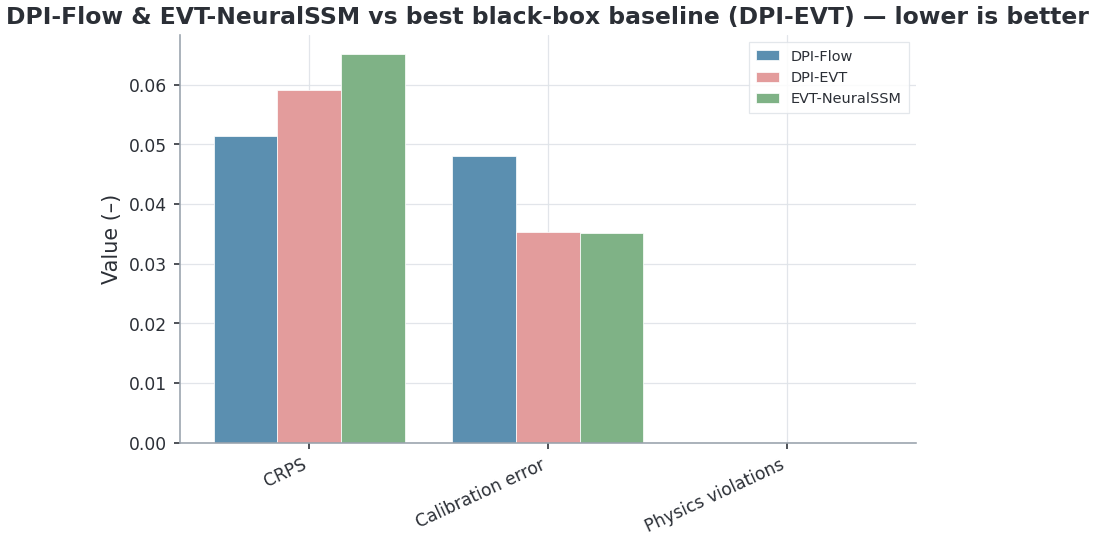

DPI-Flow: CRPS +13.1% vs DPI-EVT | calib.err 0.048 | physics-viol 0.000 | CRR RMSE 0.2047 (baselines: n/a)
EVT-NeuralSSM: CRPS -10.1% vs DPI-EVT | calib.err 0.035 | physics-viol 0.000 | CRR RMSE 0.1909 (baselines: n/a)


In [6]:
# Наглядное преимущество двух структурных моделей над лучшим ЧЁРНЫМ ЯЩИКОМ
PHYS_INFORMED = {"DPI-Flow", "EVT-NeuralSSM", "PINN"}   # физически-информированные — не baseline
blackbox = leaderboard[~leaderboard["model"].isin(PHYS_INFORMED)].dropna(subset=["Traj_CRPS"])
best_base = blackbox.sort_values("Traj_CRPS").iloc[0]["model"]
sel = leaderboard[leaderboard["model"].isin(list(PHYS_MODELS) + [best_base])].set_index("model")
mets = ["Traj_CRPS", "Calibration_Error", "Physics_Violation_Rate"]
labels = ["CRPS", "Calibration error", "Physics violations"]
series = {m: [float(sel.loc[m, k]) for k in mets] for m in sel.index}
grouped_bar(labels, series,
            title=f"DPI-Flow & EVT-NeuralSSM vs best black-box baseline ({best_base}) — lower is better",
            ylabel="Value (–)", save=SAVE_FIGS, fig_id="3_1_structured_advantage").show()
for m in PHYS_MODELS:
    if m in sel.index:
        d = (sel.loc[best_base, "Traj_CRPS"] - sel.loc[m, "Traj_CRPS"]) / sel.loc[best_base, "Traj_CRPS"] * 100
        print(f"{m}: CRPS {d:+.1f}% vs {best_base} | calib.err {sel.loc[m,'Calibration_Error']:.3f} | "
              f"physics-viol {sel.loc[m,'Physics_Violation_Rate']:.3f} | CRR RMSE {sel.loc[m,'CRR_RMSE']:.4f} (baselines: n/a)")

## P³-Score и Pareto-ранжирование (публикационное)

Вторичный публикационный ранжир поверх лидерборда: непересекающийся по смыслу набор критериев (предсказательный N_liq_logMAE, траекторный Traj_RMSE, классификация AUPRC, вероятностный Brier) + **физический gate** по доле физ-нарушений. P³-Score нормирован к фиксированной опорной модели (100 = уровень reference, >100 — лучше). Pareto-фронт — недоминируемая сортировка по тем же критериям.

In [7]:
from liquefaction_ai.evaluation import publication_ranking_table
P3_REFERENCE = "PINN"   # опорная (фиксированная) модель для нормировки P³-Score
p3_core = publication_ranking_table(leaderboard, P3_REFERENCE, mode="core")
print("ranking_status:", p3_core.attrs.get("ranking_status", "ok"))
display(english_metric_table(p3_core).round(3))
p3_core.round(4).to_csv(REPO_ROOT / "results" / "tables" / "p3_core_ranking.csv", index=False)
print("saved results/tables/p3_core_ranking.csv")

ranking_status: ok


,Model,Pareto front (raw),Pareto front (adm.),P³ Core raw,P³ Core admissible,Physically unreliable,Excluded (adm.),Physical penalty,Physics violations,log-MAE N_liq,Trajectory RMSE,Brier,AUPRC,MAE N_liq (cycles),RMSE N_liq (cycles),AUROC,ECE,Trajectory MAE,Trajectory MSE,Produces CRR
0,EVT-NeuralSSM,1.0,1.0,202.211,202.211,False,False,0.000,0.000,0.481,0.126,0.014,1.000,189.842,573.055,1.000,0.053,0.087,0.016,True
1,DPI-EVT,1.0,1.0,186.947,186.947,False,False,0.000,0.000,0.570,0.117,0.016,1.000,307.485,883.217,1.000,0.052,0.077,0.014,True
2,DPI-Flow,1.0,1.0,116.419,116.419,False,False,0.000,0.000,1.609,0.105,0.029,0.999,2064.993,3326.562,0.999,0.055,0.068,0.011,True
3,PINN,1.0,1.0,100.000,100.000,False,False,0.000,0.000,1.907,0.100,0.044,0.999,2207.825,3481.400,0.999,0.168,0.079,0.010,False
4,GRU,2.0,2.0,51.623,51.623,False,False,0.000,0.000,2.160,0.222,0.200,0.994,2243.063,3604.250,0.990,0.335,0.193,0.049,False
5,DeepState,2.0,2.0,46.786,46.786,False,False,0.000,0.000,1.984,0.356,0.190,0.996,2219.508,3578.701,0.993,0.371,0.263,0.127,False
6,LSTM,3.0,3.0,48.627,48.627,False,False,0.000,0.000,2.149,0.248,0.225,0.992,2241.727,3605.091,0.988,0.036,0.218,0.061,False
7,Transformer,2.0,NaN,91.302,0.000,True,True,4.448,0.069,1.988,0.110,0.054,1.000,2216.191,3559.571,1.000,0.199,0.088,0.012,False
8,TCN,3.0,NaN,43.752,0.000,True,True,5.191,0.079,3.220,0.247,0.195,0.981,2303.253,3665.235,0.963,0.283,0.212,0.061,False
9,Neural Spline Flow,3.0,NaN,51.735,0.000,True,True,74.250,1.000,2.507,0.272,0.127,0.994,2274.039,3634.313,0.990,0.287,0.235,0.074,False


saved results/tables/p3_core_ranking.csv


## Trajectory error and risk classification

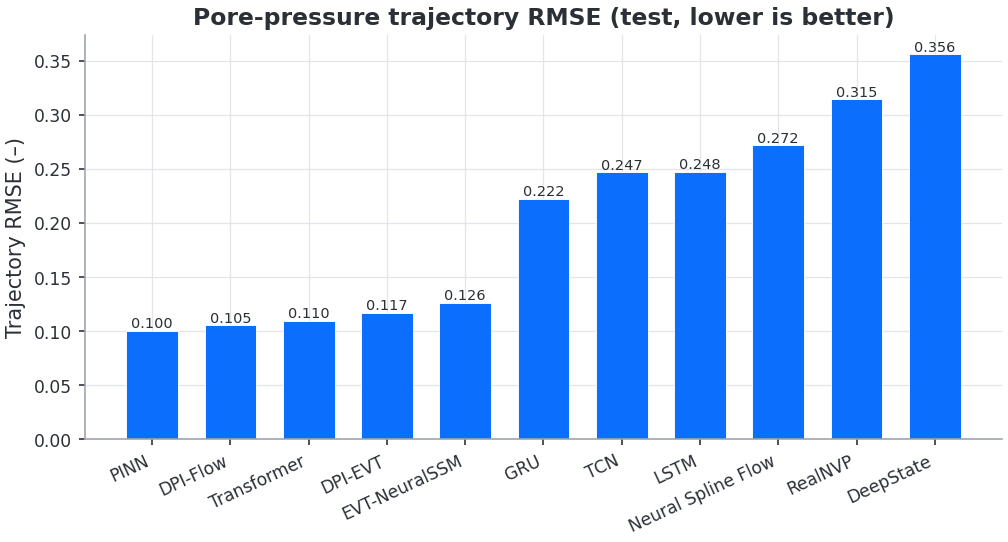

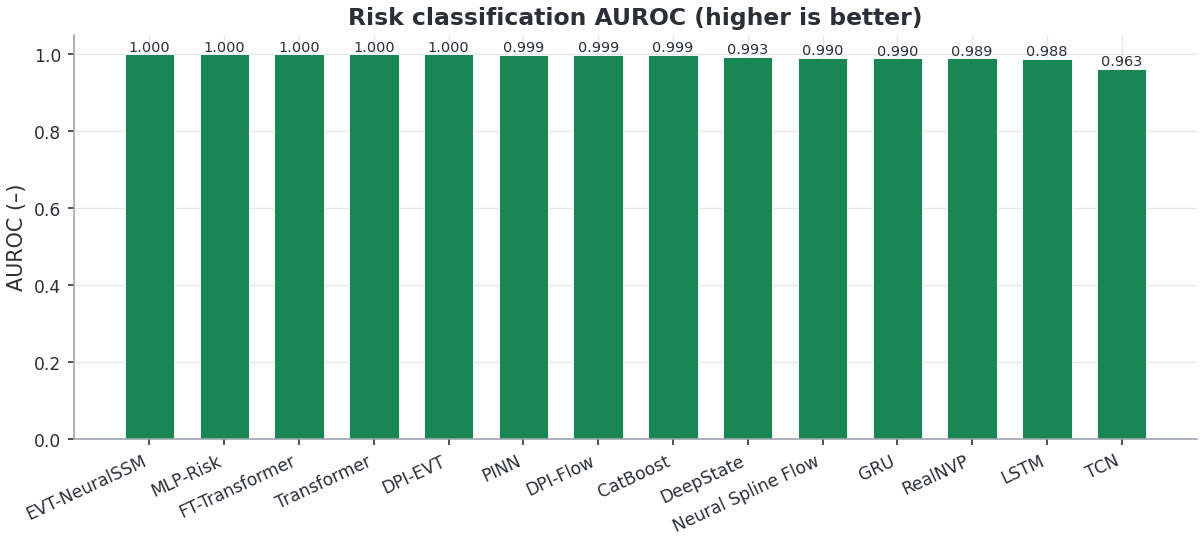

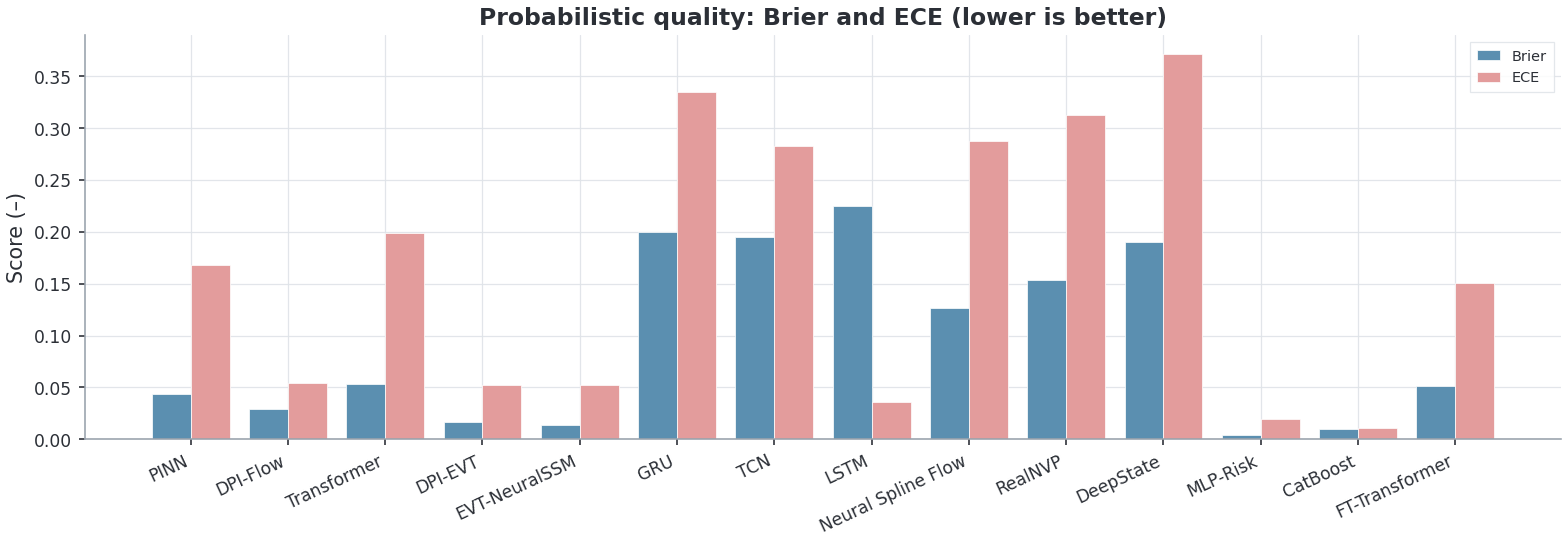

In [8]:
traj_df = leaderboard.dropna(subset=["Traj_RMSE"]).sort_values("Traj_RMSE")
bar(traj_df["model"], traj_df["Traj_RMSE"], title="Pore-pressure trajectory RMSE (test, lower is better)",
    ylabel="Trajectory RMSE (–)", color="#0b6efd", save=SAVE_FIGS, fig_id="3_1_leaderboard_rmse").show()
auc_df = leaderboard.sort_values("AUROC", ascending=False)
bar(auc_df["model"], auc_df["AUROC"], title="Risk classification AUROC (higher is better)",
    ylabel="AUROC (–)", color="#198754", save=SAVE_FIGS, fig_id="3_1_auroc").show()
grouped_bar(leaderboard["model"].tolist(),
            {"Brier": leaderboard["Brier"].tolist(), "ECE": leaderboard["ECE"].tolist()},
            title="Probabilistic quality: Brier and ECE (lower is better)", ylabel="Score (–)",
            save=SAVE_FIGS, fig_id="3_1_brier_ece").show()

## ROC curves

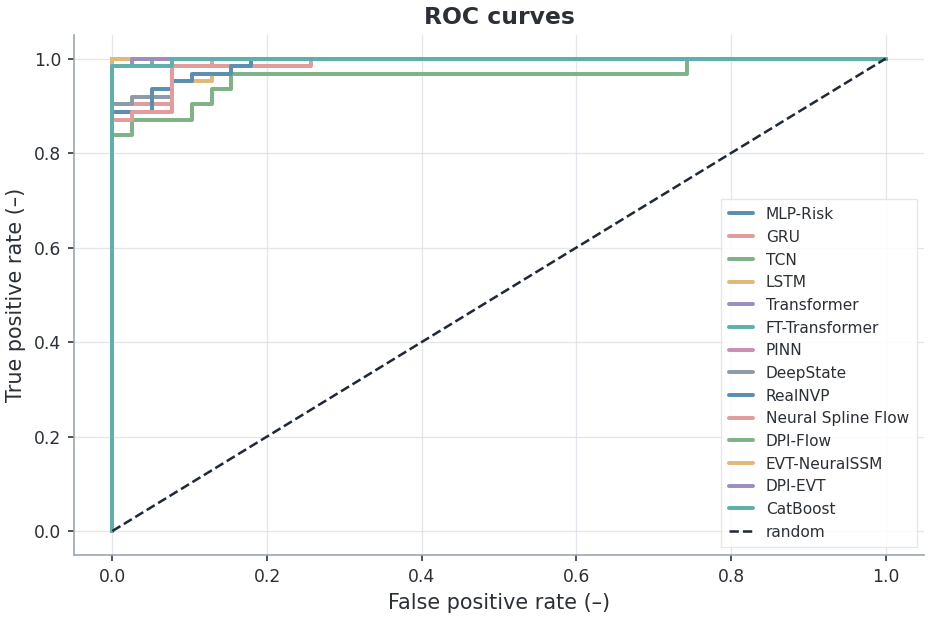

In [9]:
y_true = test["label"].cpu().numpy()
series = []
for disp, out in predictions.items():
    fpr, tpr, _ = roc_curve(y_true, out["risk_prob"])
    series.append({"x": fpr, "y": tpr, "name": disp})
series.append({"x": [0, 1], "y": [0, 1], "name": "random", "color": "#1f2937", "dash": "dash", "width": 1.4})
lines(series, title="ROC curves", xlabel="False positive rate (–)", ylabel="True positive rate (–)",
      save=SAVE_FIGS, fig_id="3_1_roc_curves").show()

## Risk calibration

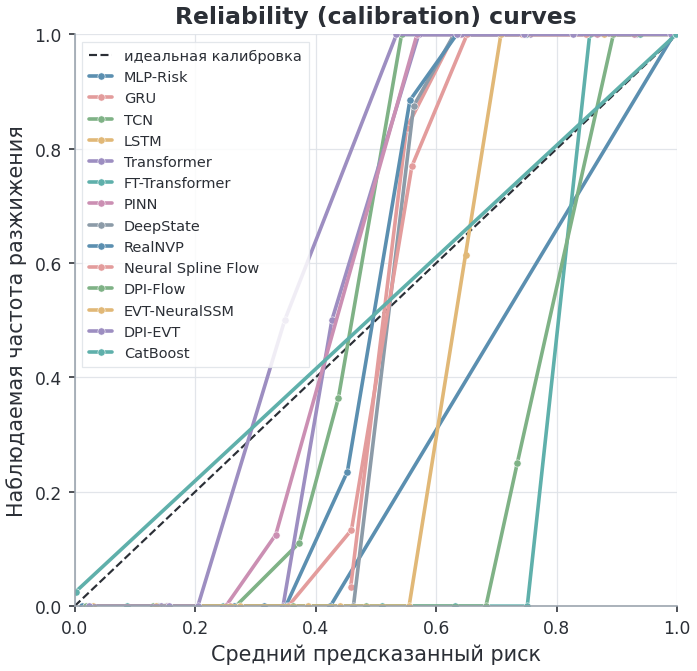

In [10]:
curves = {}
for disp in sample_tables:
    st = sample_tables[disp]
    if st["liq_label"].nunique() > 1:
        frac_pos, mean_pred = calibration_curve(st["liq_label"], st["risk_prob_pred"], n_bins=10)
        curves[disp] = (mean_pred, frac_pos)
calibration_plot(curves, title="Reliability (calibration) curves",
                 save=SAVE_FIGS, fig_id="3_1_calibration").show()

## Post-hoc temperature scaling

A single temperature T is fitted on the validation set per model and applied to the test
risk logits. This is a fair, universal post-hoc calibration step — it improves Brier/ECE
without changing AUROC (ranking is preserved).

,Model,T,Brier raw,Brier cal,ECE raw,ECE cal
0,MLP-Risk,1.10,0.0037,0.0043,0.0192,0.0230
1,GRU,0.05,0.2004,0.0576,0.3351,0.1069
2,TCN,0.05,0.1947,0.1271,0.2827,0.1569
3,LSTM,0.98,0.2251,0.2251,0.0356,0.0383
4,Transformer,0.25,0.0537,0.0113,0.1993,0.0303
5,FT-Transformer,0.17,0.0518,0.0779,0.1511,0.0826
6,PINN,0.28,0.0440,0.0113,0.1679,0.0149
7,DeepState,0.05,0.1901,0.0550,0.3715,0.1002
8,RealNVP,0.08,0.1539,0.0447,0.3127,0.0460
9,Neural Spline Flow,0.08,0.1266,0.0434,0.2875,0.0577


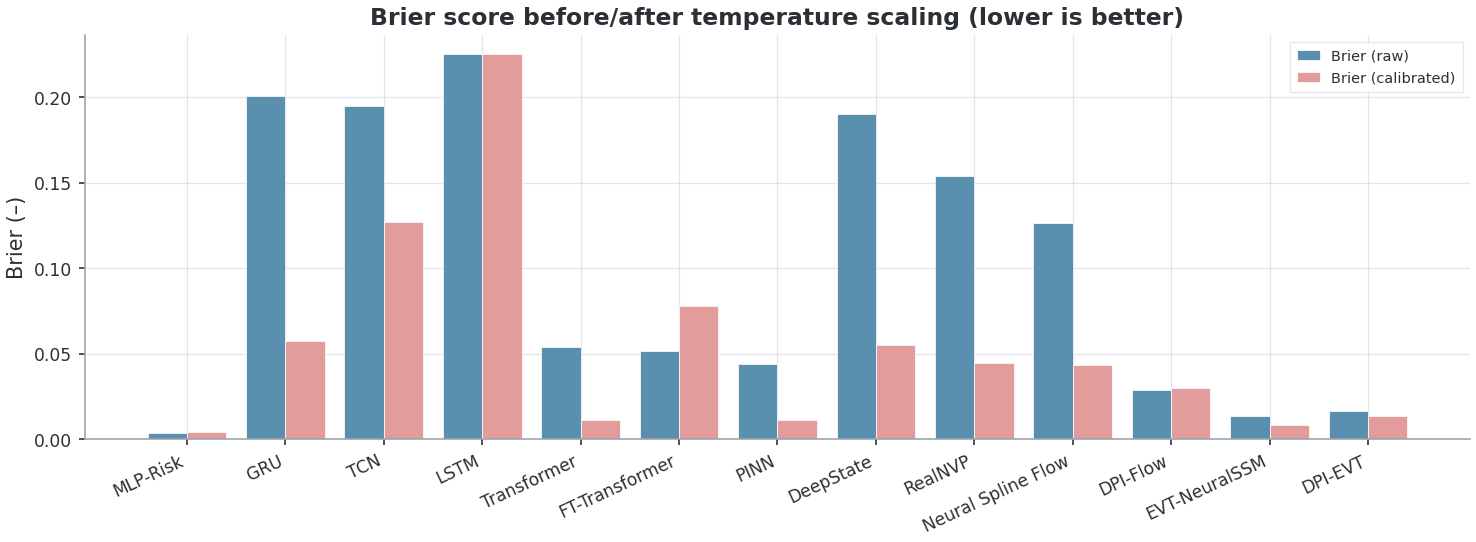

In [11]:
from liquefaction_ai.evaluation import fit_temperature, apply_temperature, expected_calibration_error, safe_binary_metrics

val = benchmark["val"]; y_val = val["label"].cpu().numpy(); y_test = test["label"].cpu().numpy()
cal_rows = []
for name in MODEL_NAMES:
    model, hp, _ = load_trained(name); disp = hp["display_name"]
    val_out = collect_outputs(model, val, config, device)
    vp = np.clip(val_out["risk_prob"], 1e-6, 1 - 1e-6); v_logit = np.log(vp / (1 - vp))
    T = fit_temperature(v_logit, y_val); T = float(np.clip(T if np.isfinite(T) else 1.0, 0.05, 20.0))
    p_raw = np.clip(np.nan_to_num(predictions[disp]["risk_prob"], nan=0.5), 1e-6, 1 - 1e-6)
    p_cal = np.clip(np.nan_to_num(apply_temperature(p_raw, T), nan=0.5), 1e-6, 1 - 1e-6)
    _, _, brier_raw = safe_binary_metrics(y_test, p_raw); ece_raw = expected_calibration_error(y_test, p_raw)
    _, _, brier_cal = safe_binary_metrics(y_test, p_cal); ece_cal = expected_calibration_error(y_test, p_cal)
    cal_rows.append({"Model": disp, "T": round(T, 2), "Brier raw": round(brier_raw, 4), "Brier cal": round(brier_cal, 4),
                     "ECE raw": round(ece_raw, 4), "ECE cal": round(ece_cal, 4)})
cal_df = pd.DataFrame(cal_rows)
display(cal_df)
grouped_bar(cal_df["Model"].tolist(), {"Brier (raw)": cal_df["Brier raw"].tolist(), "Brier (calibrated)": cal_df["Brier cal"].tolist()},
            title="Brier score before/after temperature scaling (lower is better)", ylabel="Brier (–)",
            save=SAVE_FIGS, fig_id="3_1_temperature_scaling").show()

## Uncertainty: coverage and interval width

,Model,Coverage@90%,Interval width@90%
0,PINN,0.9740,0.4338
1,DPI-Flow,0.9386,0.3407
2,Transformer,0.9846,0.5688
3,DPI-EVT,0.9250,0.3923
4,EVT-NeuralSSM,0.9229,0.4189
5,GRU,0.8493,0.5620
6,TCN,0.8469,1.0304
7,LSTM,0.9704,0.8965
8,Neural Spline Flow,0.7585,0.6969
9,RealNVP,0.7406,0.7757


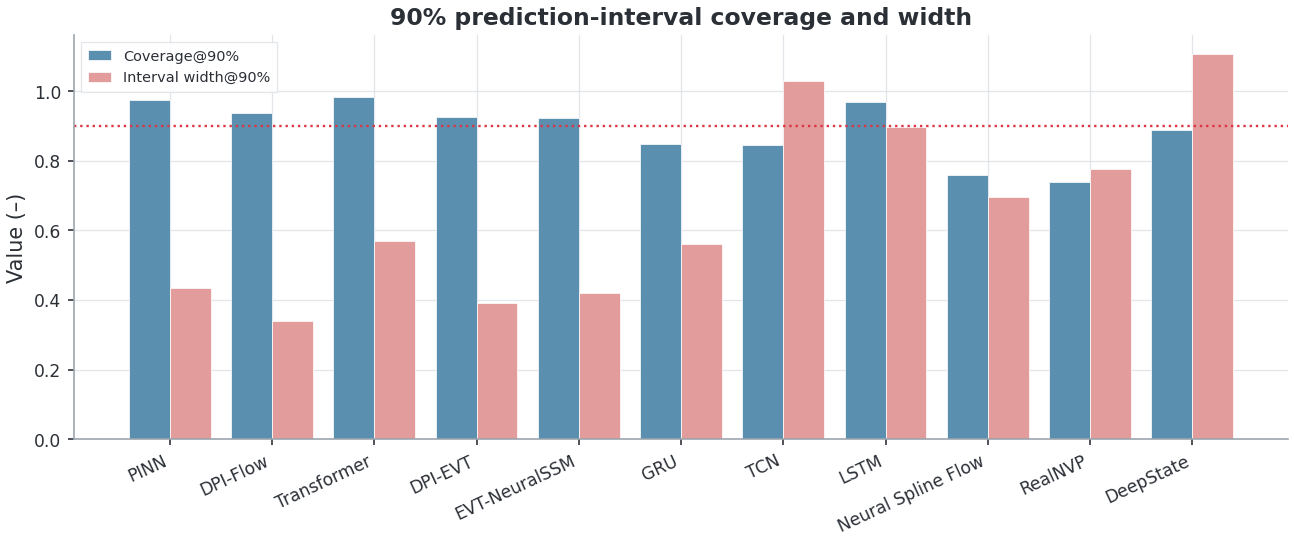

In [12]:
cov_df = leaderboard.dropna(subset=["Coverage_90"])[["model", "Coverage_90", "Interval_Width_90"]]
display(english_metric_table(cov_df).round(4))
fig = grouped_bar(cov_df["model"].tolist(),
                  {"Coverage@90%": cov_df["Coverage_90"].tolist(),
                   "Interval width@90%": cov_df["Interval_Width_90"].tolist()},
                  title="90% prediction-interval coverage and width", ylabel="Value (–)",
                  save=False, fig_id="3_1_coverage")
fig.add_hline(y=0.90, line_dash="dot", line_color="#dc3545")
from liquefaction_ai.viz import save_figure
save_figure(fig, "3_1_coverage", save=SAVE_FIGS)
fig.show()

## Итог

Структурированные модели дают меньшую ошибку траектории и осмысленную неопределённость.
Дальше — **3.2 абляции и OOD**.